In [1]:
import pandas as pd
import numpy as np
import pprint
import yfinance as yf
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import date
from statsmodels.tsa.holtwinters import (ExponentialSmoothing,SimpleExpSmoothing, Holt)

Importing plotly failed. Interactive plots will not work.


In [156]:
ticker = yf.Ticker('091230.KS')
pprint.pprint(ticker.info)

{'allTimeHigh': 165490.0,
 'allTimeLow': 8910.0,
 'ask': 163215.0,
 'askSize': 0,
 'averageDailyVolume10Day': 1331623,
 'averageDailyVolume3Month': 757887,
 'averageVolume': 757887,
 'averageVolume10days': 1331623,
 'bid': 163160.0,
 'bidSize': 0,
 'corporateActions': [],
 'cryptoTradeable': False,
 'currency': 'KRW',
 'customPriceAlertConfidence': 'LOW',
 'dayHigh': 164490.0,
 'dayLow': 160715.0,
 'esgPopulated': False,
 'exchange': 'KSC',
 'exchangeDataDelayedBy': 20,
 'exchangeTimezoneName': 'Asia/Seoul',
 'exchangeTimezoneShortName': 'KST',
 'fiftyDayAverage': 122464.4,
 'fiftyDayAverageChange': 40695.6,
 'fiftyDayAverageChangePercent': 0.33230558,
 'fiftyTwoWeekChangePercent': 409.79532,
 'fiftyTwoWeekHigh': 165490.0,
 'fiftyTwoWeekHighChange': -2330.0,
 'fiftyTwoWeekHighChangePercent': -0.0140794,
 'fiftyTwoWeekLow': 31075.0,
 'fiftyTwoWeekLowChange': 132085.0,
 'fiftyTwoWeekLowChangePercent': 4.250523,
 'fiftyTwoWeekRange': '31075.0 - 165490.0',
 'firstTradeDateMilliseconds': 11

In [157]:
df = ticker.history(period='5y')
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-05-24 00:00:00+09:00,36545.169970,36545.169970,35484.911841,35552.382812,94440,0.0,0.0,0.0
2021-05-25 00:00:00+09:00,35855.996315,36096.964032,35793.344708,35798.164062,41586,0.0,0.0,0.0
2021-05-26 00:00:00+09:00,36130.701070,36130.701070,35696.959161,35904.191406,42609,0.0,0.0,0.0
2021-05-27 00:00:00+09:00,36111.428608,36381.312500,35509.009207,36381.312500,28733,0.0,0.0,0.0
2021-05-28 00:00:00+09:00,36530.704961,36530.704961,36135.517915,36304.195312,25992,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-05-18 00:00:00+09:00,149240.000000,156800.000000,143535.000000,153825.000000,1453351,0.0,0.0,0.0
2026-05-19 00:00:00+09:00,150010.000000,151925.000000,144505.000000,147770.000000,929164,0.0,0.0,0.0
2026-05-20 00:00:00+09:00,147770.000000,150625.000000,143745.000000,146945.000000,1612412,0.0,0.0,0.0


In [158]:
df = yf.download('091230.KS',
                start = '2018-01-01',
                end = '2024-12-31',
                progress=False)
df

Price,Close,High,Low,Open,Volume
Ticker,091230.KS,091230.KS,091230.KS,091230.KS,091230.KS
2018-01-02,26108.939453,26376.314507,25963.524950,26376.314507,6264
2018-01-03,26132.390625,26465.436709,26015.120877,26310.640642,88926
2018-01-04,25705.531250,26315.333999,25705.531250,26263.735305,8050
2018-01-05,25940.068359,26066.719688,25775.890712,25775.890712,2514
2018-01-08,25424.087891,26071.417066,25137.949632,26071.417066,24768
...,...,...,...,...,...
2024-12-23,29488.273438,29754.956868,28757.363294,28757.363294,49743
2024-12-24,29517.906250,30016.703060,29394.441693,30016.703060,43795
2024-12-26,29117.878906,29833.973282,29108.001742,29833.973282,36303


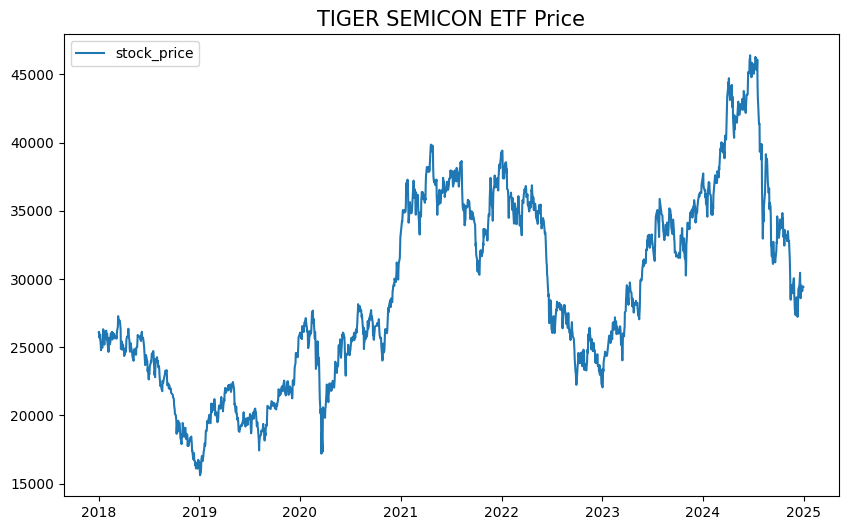

In [5]:
fig = plt.figure(figsize =(10,6))
plt.plot(df.index, df.Close, label='stock_price')
plt.legend()
plt.title('TIGER SEMICON ETF Price', fontsize=15)
plt.show()

In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1692 entries, 2018-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 091230.KS)   1692 non-null   float64
 1   (High, 091230.KS)    1692 non-null   float64
 2   (Low, 091230.KS)     1692 non-null   float64
 3   (Open, 091230.KS)    1692 non-null   float64
 4   (Volume, 091230.KS)  1692 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 79.3 KB


In [7]:
moving_average = df['Close'].rolling(window=10).mean() # rolling(window=num).mean() >> num크기의 이동평균 구하는 함수
moving_average

Ticker,091230.KS
2018-01-02,NaN
2018-01-03,NaN
2018-01-04,NaN
2018-01-05,NaN
2018-01-08,NaN
...,...
2024-12-23,29237.886133
2024-12-24,29425.058594
2024-12-26,29496.174414
2024-12-27,29509.014648


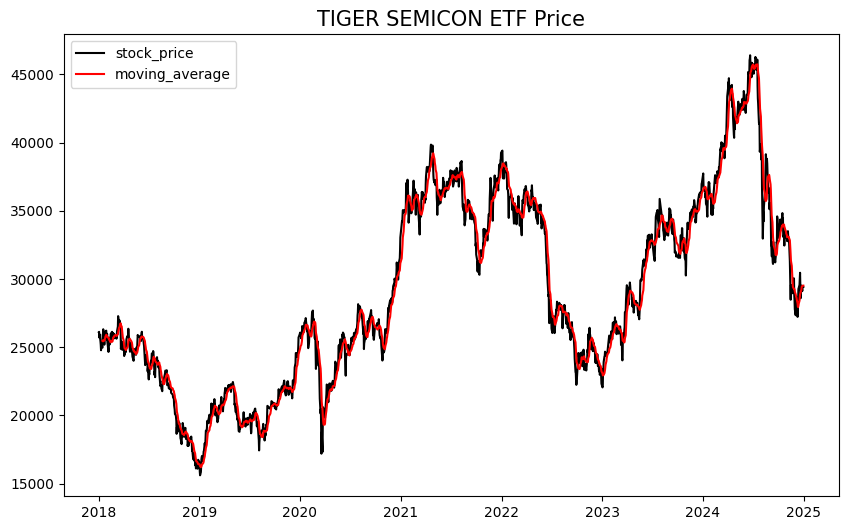

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize =(10,6))
fig.set_facecolor('white')
plt.plot(df.index, df.Close, color = 'k', label='stock_price')
plt.plot(moving_average.index, moving_average, color='red', label='moving_average')
plt.legend()
plt.title('TIGER SEMICON ETF Price', fontsize=15)
plt.show()

In [9]:
df_indices = df.index >= '2024-01-01'
df_2025 = df[df_indices]
df_2025.head()

Price,Close,High,Low,Open,Volume
Ticker,091230.KS,091230.KS,091230.KS,091230.KS,091230.KS
2024-01-02,37741.261719,37741.261719,36733.845228,37043.441515,249114
2024-01-03,36871.441406,37156.466543,36532.359778,36984.468616,409910
2024-01-04,36704.355469,37205.606541,36394.759218,36660.127433,351615
2024-01-05,36640.468750,36640.468750,36208.016866,36527.441553,264395
2024-01-08,36453.730469,36753.498271,36311.217907,36424.245111,201570


In [10]:
train_indices = df.index < '2024-01-01'
df_train = df[train_indices]
df_test = df[~train_indices]

In [11]:
df_train

Price,Close,High,Low,Open,Volume
Ticker,091230.KS,091230.KS,091230.KS,091230.KS,091230.KS
2018-01-02,26108.939453,26376.314507,25963.524950,26376.314507,6264
2018-01-03,26132.390625,26465.436709,26015.120877,26310.640642,88926
2018-01-04,25705.531250,26315.333999,25705.531250,26263.735305,8050
2018-01-05,25940.068359,26066.719688,25775.890712,25775.890712,2514
2018-01-08,25424.087891,26071.417066,25137.949632,26071.417066,24768
...,...,...,...,...,...
2023-12-21,36340.710938,36340.710938,35785.403252,36026.200390,154199
2023-12-22,36335.789062,36856.697047,36335.789062,36660.127997,169701
2023-12-26,36306.304688,36561.844461,36045.850688,36502.873744,83080


In [12]:
df_test

Price,Close,High,Low,Open,Volume
Ticker,091230.KS,091230.KS,091230.KS,091230.KS,091230.KS
2024-01-02,37741.261719,37741.261719,36733.845228,37043.441515,249114
2024-01-03,36871.441406,37156.466543,36532.359778,36984.468616,409910
2024-01-04,36704.355469,37205.606541,36394.759218,36660.127433,351615
2024-01-05,36640.468750,36640.468750,36208.016866,36527.441553,264395
2024-01-08,36453.730469,36753.498271,36311.217907,36424.245111,201570
...,...,...,...,...,...
2024-12-23,29488.273438,29754.956868,28757.363294,28757.363294,49743
2024-12-24,29517.906250,30016.703060,29394.441693,30016.703060,43795
2024-12-26,29117.878906,29833.973282,29108.001742,29833.973282,36303


In [13]:
ses_1 = SimpleExpSmoothing(df_train.Close).fit(smoothing_level=0.2)
ses_forecast_1 = ses_1.forecast(len(df_test))
ses_forecast_1.index = df_test.index

ses_2 = SimpleExpSmoothing(df_train.Close).fit(smoothing_level=0.5)
ses_forecast_2 = ses_2.forecast(len(df_test))
ses_forecast_2.index = df_test.index

ses_3 = SimpleExpSmoothing(df_train.Close).fit()
alpha = ses_3.model.params["smoothing_level"]
ses_forecast_3 = ses_3.forecast(len(df_test))
ses_forecast_3.index = df_test.index

C:\Project\Python_Source\AI01\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Project\Python_Source\AI01\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pred

In [14]:
COLORS = [plt.cm.cubehelix(x) for x in [0.1, 0.3, 0.5, 0.7]]

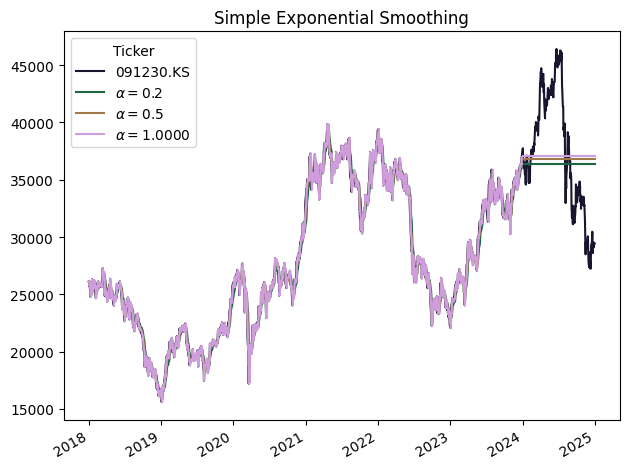

In [15]:
df.Close.plot(color=COLORS[0],
               title='Simple Exponential Smoothing',
               label = 'Actual',
               legend=True)

ses_forecast_1.plot(color=COLORS[1], legend=True, label=r"$\alpha=0.2$")
ses_1.fittedvalues.plot(color=COLORS[1])

ses_forecast_2.plot(color=COLORS[2], legend=True, label=r"$\alpha=0.5$")
ses_2.fittedvalues.plot(color=COLORS[2])

ses_forecast_3.plot(color=COLORS[3], legend=True, label=r"$\alpha={0:.4f}$".format(alpha))
ses_3.fittedvalues.plot(color=COLORS[3])

plt.tight_layout()
plt.show()

In [30]:
df['ds'] = df.index
df['y'] = df['Close']

In [31]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1692 entries, 2018-01-02 to 2024-12-30
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   (Close, 091230.KS)   1692 non-null   float64      
 1   (High, 091230.KS)    1692 non-null   float64      
 2   (Low, 091230.KS)     1692 non-null   float64      
 3   (Open, 091230.KS)    1692 non-null   float64      
 4   (Volume, 091230.KS)  1692 non-null   int64        
 5   (ds, )               1692 non-null   datetime64[s]
 6   (y, )                1692 non-null   float64      
dtypes: datetime64[s](1), float64(5), int64(1)
memory usage: 105.8 KB


In [32]:
data = df[['ds', 'y']]
train = data[data.ds < '2024-01-01']
test = data[data.ds >= '2024-01-01']
print(train.head(2))
print(test.head(2))

Price              ds             y
Ticker                             
2018-01-02 2018-01-02  26108.939453
2018-01-03 2018-01-03  26132.390625
Price              ds             y
Ticker                             
2024-01-02 2024-01-02  37741.261719
2024-01-03 2024-01-03  36871.441406


In [180]:
# prophet_m = Prophet(changepoint_prior_scale=0.01, seasonality_mode='multiplicative').fit(train)
prophet_m = Prophet(changepoint_prior_scale=0.01).fit(train)

17:32:10 - cmdstanpy - INFO - Chain [1] start processing
17:32:10 - cmdstanpy - INFO - Chain [1] done processing


In [181]:
future = pd.DataFrame(test.ds)

In [182]:
forecast = prophet_m.predict(future)

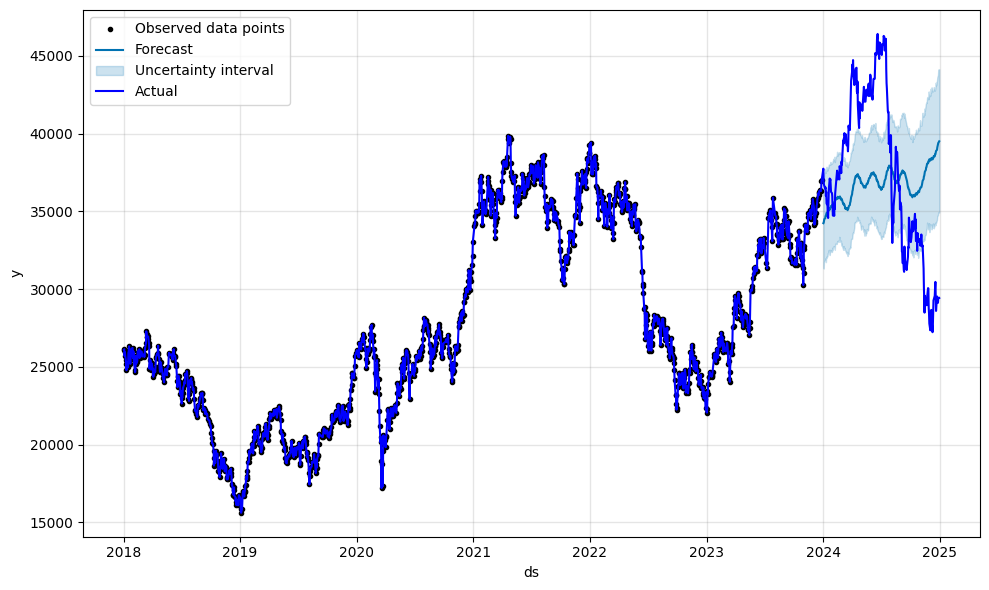

In [187]:
prophet_m.plot(forecast)
plt.plot(data.ds, data.y, color='b', label='Actual')
plt.legend()
plt.show()

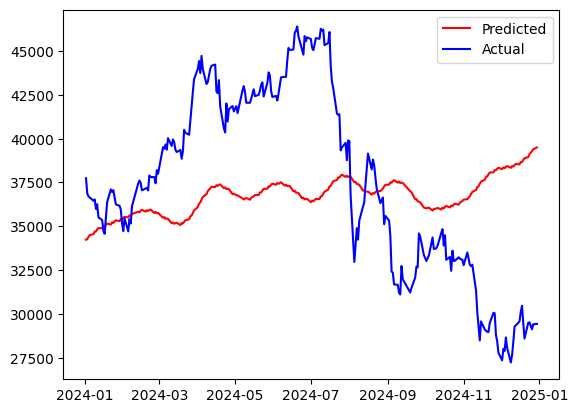

In [188]:
plt.plot(forecast.ds, forecast.yhat, color='r', label='Predicted')
plt.plot(test.ds, test.y, color='b', label='Actual')
plt.legend()
plt.show()

In [189]:
y_true = test['y']
y_pred = forecast['yhat'].values

In [190]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae)

MAE: 4933.239
